In [83]:
# Customer Segmentation using K-Means

## Data Preprocessing
## Elbow Method
## Clustering
## Results

In [84]:
import pandas as pd
file_path = "D:\\college\\Sem\\Sem 6\\Foundations of Data Science\\Project\\ecommerce-project\\data\\new_raw_data.csv" 
df = pd.read_csv(file_path)
print(df.head())

            Timestamp   Q1. Age Group     Q2. Gender        Q3. Occupation    \
0  3/25/2026 12:37:46           18 - 30           Male               Student   
1  3/25/2026 12:43:01           18 - 30           Male               Student   
2  3/25/2026 12:43:45              > 50           Male                 Other   
3  3/25/2026 12:44:51              > 50         Female  Working Professional   
4  3/25/2026 12:45:00           18 - 30           Male               Student   

  Q4.  Monthly Income Range    Q5. Which e-commerce platforms do you use?    \
0                    < 10000                                       Flipkart   
1                    < 10000                       Amazon, Flipkart, Myntra   
2                   > 100000                       Amazon, Flipkart, Others   
3                   > 100000         Amazon, Flipkart, Meesho, Myntra, Ajio   
4                    < 10000         Amazon, Flipkart, Meesho, Myntra, Ajio   

    Q6. Primary platform you use most often 

In [85]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [86]:
df = pd.read_csv("../data/new_raw_data.csv")
df.head()

,Timestamp,Q1. Age Group,Q2. Gender,Q3. Occupation,Q4. Monthly Income Range,Q5. Which e-commerce platforms do you use?,Q6. Primary platform you use most often,Q7. How often do you shop online?,Q8. Average monthly spending on e-commerce,Q9. What type of products do you buy most?,...,Q11. What influences your purchase decision the most?,Q12. Do you compare prices across platforms before buying?,Q13. Rate your satisfaction with your primary platform,Q14. Importance of price in choosing platform,Q15. Importance of delivery speed,Q16. Importance of product variety,Q17. Importance of return/refund policy,Q18. Have you faced delivery issues?,Q19. Preferred delivery time,Q20. Preferred payment method
0,3/25/2026 12:37:46,18 - 30,Male,Student,< 10000,Flipkart,Flipkart,Rarely,< 1000,Clothing,...,Price,Always,4,4,4,4,5,Yes,1 - 3 days,COD
1,3/25/2026 12:43:01,18 - 30,Male,Student,< 10000,"Amazon, Flipkart, Myntra",Amazon,Rarely,< 1000,Electronics,...,Reviews,Always,5,4,3,4,5,Yes,1 - 3 days,UPI
2,3/25/2026 12:43:45,> 50,Male,Other,> 100000,"Amazon, Flipkart, Others",Flipkart,Weekly,3000 - 7000,Groceries,...,Reviews,Always,4,4,4,5,5,Yes,1 - 3 days,Debit/Credit card
3,3/25/2026 12:44:51,> 50,Female,Working Professional,> 100000,"Amazon, Flipkart, Meesho, Myntra, Ajio",Amazon,Monthly,1000 - 3000,Clothing,...,Reviews,Sometimes,5,4,3,5,5,Yes,3 - 7 days,UPI
4,3/25/2026 12:45:00,18 - 30,Male,Student,< 10000,"Amazon, Flipkart, Meesho, Myntra, Ajio",Amazon,Monthly,7000+,Groceries,...,Brand,Always,5,5,5,5,5,No,1 - 3 days,UPI


In [87]:
df.columns = [
    "timestamp","age","gender","occupation","income",
    "platforms_used","primary_platform","shopping_frequency",
    "monthly_spending","primary_category","secondary_category",
    "purchase_factor","price_compare","satisfaction",
    "price_importance","delivery_importance",
    "variety_importance","return_importance",
    "delivery_issue","delivery_days","payment_method"
]

In [88]:
df["age"] = df["age"].replace({
    "< 18": 15, "18 - 30": 24, "30 - 50": 40, "> 50": 60
})

df["income"] = df["income"].replace({
    "< 10000": 5000, "10000-30000": 20000,
    "30000-60000": 45000, "60000-100000": 80000,
    "> 100000": 120000
})

df["shopping_frequency"] = df["shopping_frequency"].replace({
    "Daily": 30, "Weekly": 12, "Monthly": 4, "Rarely": 1
})

df["monthly_spending"] = df["monthly_spending"].replace({
    "< 1000": 800, "1000 - 3000": 2000,
    "3000 - 7000": 5000, "7000+": 8000
})

In [89]:
cols = ["age", "income", "monthly_spending", "shopping_frequency","satisfaction"]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [90]:
df[cols] = df[cols].fillna(df[cols].mean())

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cols])

In [92]:
from sklearn.decomposition import KernelPCA

In [93]:
kpca = KernelPCA(n_components=2, kernel='rbf')

X_kpca = kpca.fit_transform(X_scaled)

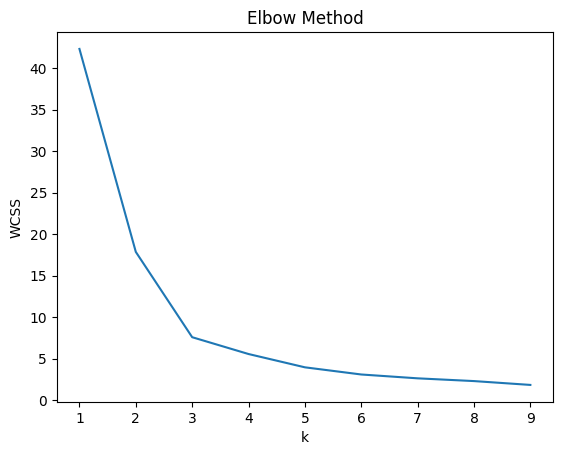

In [94]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_kpca)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [95]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
df["cluster"] = kmeans.fit_predict(X_kpca)

df.head()

,timestamp,age,gender,occupation,income,platforms_used,primary_platform,shopping_frequency,monthly_spending,primary_category,...,price_compare,satisfaction,price_importance,delivery_importance,variety_importance,return_importance,delivery_issue,delivery_days,payment_method,cluster
0,3/25/2026 12:37:46,24,Male,Student,5000,Flipkart,Flipkart,1,800,Clothing,...,Always,4,4,4,4,5,Yes,1 - 3 days,COD,1
1,3/25/2026 12:43:01,24,Male,Student,5000,"Amazon, Flipkart, Myntra",Amazon,1,800,Electronics,...,Always,5,4,3,4,5,Yes,1 - 3 days,UPI,1
2,3/25/2026 12:43:45,60,Male,Other,120000,"Amazon, Flipkart, Others",Flipkart,12,5000,Groceries,...,Always,4,4,4,5,5,Yes,1 - 3 days,Debit/Credit card,0
3,3/25/2026 12:44:51,60,Female,Working Professional,120000,"Amazon, Flipkart, Meesho, Myntra, Ajio",Amazon,4,2000,Clothing,...,Sometimes,5,4,3,5,5,Yes,3 - 7 days,UPI,2
4,3/25/2026 12:45:00,24,Male,Student,5000,"Amazon, Flipkart, Meesho, Myntra, Ajio",Amazon,4,8000,Groceries,...,Always,5,5,5,5,5,No,1 - 3 days,UPI,0


In [96]:
cluster_summary = df.groupby("cluster")[[
    "age","income","monthly_spending","shopping_frequency","satisfaction"
]].mean()

cluster_summary

,age,income,monthly_spending,shopping_frequency,satisfaction
cluster,,,,,
0,48.565217,86630.434783,5573.913043,10.434783,4.217391
1,24.952381,14365.079365,1495.238095,3.174603,3.936508
2,56.744186,110930.232558,1832.558140,3.813953,3.581395


In [97]:
def label_cluster(row):
    if row["cluster"] == 0:
        return "High Value Customers: Working professionals"
    elif row["cluster"] == 1:
        return "Low value Customers : Students"
    else:
        return "Potential Customers : Senior citizens"

df["customer_segment"] = df.apply(label_cluster, axis=1)

In [98]:
df[["cluster", "customer_segment"]].head()

,cluster,customer_segment
0,1,Low value Customers : Students
1,1,Low value Customers : Students
2,0,High Value Customers: Working professionals
3,2,Potential Customers : Senior citizens
4,0,High Value Customers: Working professionals


In [99]:
df.to_csv("clustered_data_final_data.csv", index=False)

In [100]:
cluster_summary = df.groupby("cluster")[[
    "age","income","monthly_spending","shopping_frequency","satisfaction"
]].mean()

cluster_summary

,age,income,monthly_spending,shopping_frequency,satisfaction
cluster,,,,,
0,48.565217,86630.434783,5573.913043,10.434783,4.217391
1,24.952381,14365.079365,1495.238095,3.174603,3.936508
2,56.744186,110930.232558,1832.558140,3.813953,3.581395


In [101]:
mapping = {
    0: "High Value Customers : Working professionals",
    1: "Low value Customers : Students",
    2: "Potential Customers : Senior citizens",

}

df["customer_segment"] = df["cluster"].map(mapping)

In [102]:
df["customer_segment"].value_counts()

customer_segment
Low value Customers : Students                  63
High Value Customers : Working professionals    46
Potential Customers : Senior citizens           43
Name: count, dtype: int64

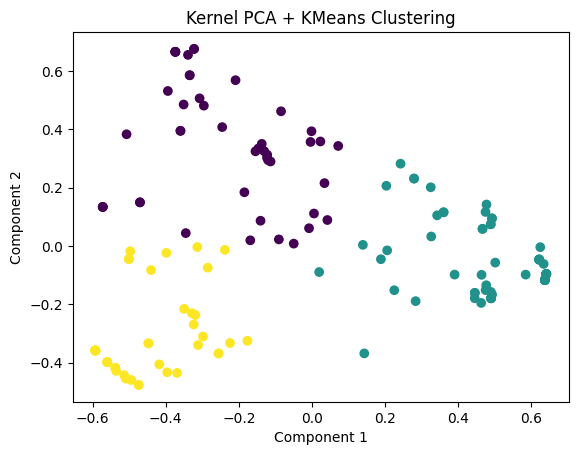

In [103]:
# -----------------------------
# VISUALIZATION
# -----------------------------
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=df["cluster"])
plt.title("Kernel PCA + KMeans Clustering")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

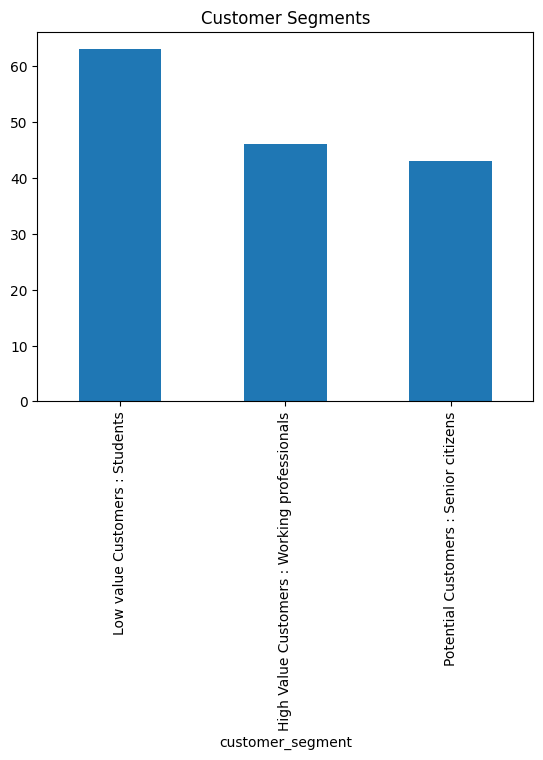

In [104]:
import matplotlib.pyplot as plt

df["customer_segment"].value_counts().plot(kind="bar")
plt.title("Customer Segments")
plt.show()